# 1. MOUNT THE GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gdown

# 2. DOWNLOAD THE DATASET

In [26]:
import gdown

file_id = "17CzHmnOQhnK7D05aK6ZsGp3Jv11YOmEy"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "lung_parenchyma_seg_dataset.rar", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=17CzHmnOQhnK7D05aK6ZsGp3Jv11YOmEy
From (redirected): https://drive.google.com/uc?id=17CzHmnOQhnK7D05aK6ZsGp3Jv11YOmEy&confirm=t&uuid=11d13f5e-fb2e-4279-aebf-c265a4b11850
To: /content/lung_parenchyma_seg_dataset.rar
100%|██████████| 2.27G/2.27G [00:38<00:00, 58.2MB/s]


'lung_parenchyma_seg_dataset.rar'

# 3. EXTRACT DATASET

In [27]:
!unrar x lung_parenchyma_seg_dataset.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from lung_parenchyma_seg_dataset.rar


Would you like to replace the existing file lung_parenchyma_seg_dataset/VAL/IMAGES/VESSEL12_010042.png
471984 bytes, modified on 2021-09-22 18:16
with a new one
471984 bytes, modified on 2021-09-22 18:16

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit y

Extracting  lung_parenchyma_seg_dataset/VAL/IMAGES/VESSEL12_010042.png       0%  OK 

Would you like to replace the existing file lung_parenchyma_seg_dataset/VAL/IMAGES/VESSEL12_010043.png
470540 bytes, modified on 2021-09-22 18:16
with a new one
470540 bytes, modified on 2021-09-22 18:16

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit y

Extracting  lung_parenchyma_seg_dataset/VAL/IMAGES/VESSEL12_010043.png       0%  OK 

Would you like to replace the existing file lung_parenchyma_seg_dataset/VAL/IMAGES/VESSEL12_010044.png
471418 bytes, modified on 2021-09-22 18:16
with a new one
471418 bytes, m

# 4. IMPORT THE PYTHON LIBRARIES

In [28]:
import tqdm as tqdm
from tensorflow import keras
from tensorflow.keras import layers
import os, glob
import matplotlib.pyplot as plt
import cv2
import random
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
from keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose, BatchNormalization, ReLU
from keras.callbacks import ModelCheckpoint, History
import tensorflow.keras.backend as K

# 5. LOAD THE DATA PATHS AND SET THE PATH VARIABLES

In [29]:
TrainPath = r'/content/lung_parenchyma_seg_dataset/TRAIN'

ImagePath = os.path.join(TrainPath, 'IMAGES')
LabelPath = os.path.join(TrainPath, 'LABELS')

print(ImagePath, '\n', LabelPath)

/content/lung_parenchyma_seg_dataset/TRAIN/IMAGES 
 /content/lung_parenchyma_seg_dataset/TRAIN/LABELS


In [30]:
ValPath = r'/content/lung_parenchyma_seg_dataset/VAL'

ValImagePath = os.path.join(ValPath, 'IMAGES')
ValLabelPath = os.path.join(ValPath, 'LABELS')

print(ValImagePath, '\n', ValLabelPath)

/content/lung_parenchyma_seg_dataset/VAL/IMAGES 
 /content/lung_parenchyma_seg_dataset/VAL/LABELS


# 6. PREPROCESS AND PREPARE THE DATA IN THE FORM OF TENSOR

<div style="background-color:#f4f8fb; padding:20px; border-radius:12px; border-left:6px solid #2E86C1;">

<h2 style="color:#2E86C1;">Image Loading and Preprocessing Function</h2>

<p style="font-size:16px;">
Before training a deep learning model such as <b>U-Net</b>, the input CT images must be prepared in a structured and consistent format.
The <code>preprocess_images()</code> function performs a sequence of preprocessing operations that convert raw image files into
normalized tensors suitable for training.
</p>

<hr>

<h3 style="color:#1F618D;">1. Parameter Initialization</h3>

<ul style="font-size:15px;">
<li><b>eps = 1e-7</b> : A very small constant added during normalization to prevent division-by-zero errors.</li>
<li><b>img_rows = 256</b> : Target height of the image.</li>
<li><b>img_columns = 256</b> : Target width of the image.</li>
</ul>

<p>
These parameters ensure that every image in the dataset is resized to a consistent spatial resolution.
</p>

<hr>

<h3 style="color:#1F618D;">2. Function Definition</h3>

<p>
The function <code>preprocess_images(path)</code> accepts the directory path containing the input images and performs several preprocessing steps.
</p>

<ul>
<li>Reads images from the specified directory</li>
<li>Converts images to grayscale</li>
<li>Resizes them to a fixed resolution</li>
<li>Normalizes pixel intensities</li>
<li>Converts them into a tensor suitable for neural network training</li>
</ul>

<hr>

<h3 style="color:#1F618D;">3. Image File Collection</h3>

<p>
All PNG images present in the directory are collected using the <code>glob</code> library.
</p>

<ul>
<li><code>glob.glob(path + '/*.png')</code> retrieves all PNG files</li>
<li>The list is sorted to maintain consistent ordering</li>
<li>The total number of images is printed for verification</li>
</ul>

<hr>

<h3 style="color:#1F618D;">4. Image Processing Loop</h3>

<p>
Each image is processed individually inside a loop. The <code>tqdm</code> library is used to display a progress bar during processing.
</p>

<p><b>Processing steps performed on each image:</b></p>

<ol>
<li>Read the image using <code>cv2.imread()</code></li>
<li>Convert the image from RGB to grayscale using <code>cv2.cvtColor()</code></li>
<li>Resize the image to <b>256 × 256</b> pixels</li>
<li>Convert the image to a floating-point NumPy array</li>
</ol>

<hr>

<h3 style="color:#1F618D;">5. Image Normalization</h3>

<p>
Pixel intensities are normalized to the range <b>[0,1]</b> using min-max normalization:
</p>

<p style="background:#ffffff; padding:10px; border-radius:6px; font-family:monospace;">
Normalized Image = (Image - min(Image)) / (max(Image) - min(Image) + eps)
</p>

<ul>
<li>This improves numerical stability during training.</li>
<li>It ensures consistent intensity scaling across all images.</li>
</ul>

<hr>

<h3 style="color:#1F618D;">6. Creating the Dataset Tensor</h3>

<p>
All processed images are stored in a Python list and later converted into a NumPy array.
</p>

<ul>
<li><code>np.asarray()</code> converts the list into a tensor</li>
<li><code>ImageArray[..., np.newaxis]</code> adds a channel dimension</li>
</ul>

<p>
This converts the data into the shape:
</p>

<p style="background:#ffffff; padding:10px; border-radius:6px; font-family:monospace;">
(Number of Images, Height, Width, Channels)
</p>

<p>
For grayscale images, the number of channels equals <b>1</b>.
</p>

<hr>

<h3 style="color:#1F618D;">7. Final Output</h3>

<p>
The function returns a 4-dimensional tensor containing all preprocessed images, which can directly be used as input to the neural network.
</p>

<p style="background:#ffffff; padding:10px; border-radius:6px; font-family:monospace;">
Example Output Shape: (N, 256, 256, 1)
</p>

<p>
Here, <b>N</b> represents the number of images in the dataset.
</p>

</div>

In [1]:
eps = 1e-7
img_rows = 256
img_columns = 256

def preprocess_images(path): #, temp = 5000
  '''preprocess functions take the images
    read them, resize them convert them to array
    normalize the images, and convert it to a trainable tensor'''
  ImageList=[]
  img_list=glob.glob(path + '/*.png')
  img_list.sort()
  #img_list = img_list[:temp]
  #print()
  print("No of images found:"+str(len(img_list)))
  for ii in tqdm.tqdm(range(len(img_list))):
    img = cv2.imread(img_list[ii])
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_img = cv2.resize(gray_img, (img_rows,img_columns))
    img_array = np.array(gray_img, dtype = np.float32)
    norm_im_array = (img_array - np.min(img_array))/((np.max(img_array) - np.min(img_array)+eps))
    ImageList.append(norm_im_array)
  ImageArray = np.asarray(ImageList, dtype = np.float32)
  ImageArray = ImageArray[..., np.newaxis]
  return ImageArray

In [2]:
X_train = preprocess_images(ImagePath)
Y_train = preprocess_images(LabelPath)

X_val = preprocess_images(ValImagePath)
Y_val = preprocess_images(ValLabelPath)

NameError: name 'ImagePath' is not defined

# 7. SANITY CHECK ON THE DATASET

<h2 style="color:#2E86C1;">Sanity Checks and Data Verification</h2>

<p style="font-size:16px;">
Before training a deep learning model, it is essential to perform
<b>sanity checks</b> on the dataset. These checks help verify that the
images and corresponding segmentation masks are loaded correctly,
aligned properly, and stored in the expected tensor format.
</p>

<p style="font-size:16px;">
In medical image segmentation tasks such as <b>lung parenchyma segmentation</b>,
incorrect preprocessing or misaligned masks can lead to poor model training.
Therefore, verifying the dataset visually and structurally is a crucial step
before starting the training process.
</p>

<hr>

<h3 style="color:#117A65;">Why Sanity Checks Are Important</h3>

<ul style="font-size:15px;">
<li><b>Verify tensor dimensions</b> to ensure the dataset shape matches the expected input format for the neural network.</li>
<li><b>Confirm correct pairing of images and masks</b> so that each CT image corresponds to the correct segmentation mask.</li>
<li><b>Detect preprocessing errors</b> such as incorrect resizing, normalization issues, or channel mismatches.</li>
<li><b>Ensure visual correctness</b> by displaying image–mask pairs before model training.</li>
<li><b>Prevent training failures</b> that can occur due to incorrectly formatted data.</li>
</ul>

<hr>

<h3 style="color:#117A65;">Random Sample Visualization</h3>

<p style="font-size:15px;">
The following code snippet randomly selects an image from the training dataset
and visualizes both the <b>input CT image</b> and its corresponding
<b>segmentation mask</b>. This helps confirm that:
</p>

<ul style="font-size:15px;">
<li>The dataset has been loaded correctly.</li>
<li>The image and mask correspond to the same anatomical slice.</li>
<li>The segmentation mask correctly highlights the target region.</li>
</ul>

<hr>

<h3 style="color:#117A65;">Code Explanation</h3>

<ol style="font-size:15px;">

<li>
<b>Select a Random Training Sample</b><br>
A random index is generated using the <code>random.randint()</code> function.
This ensures that a different sample from the training dataset is visualized
each time the code is executed.
</li>

<br>

<li>
<b>Print the Selected Index</b><br>
Printing the index helps track which sample is being displayed, which can be
useful during debugging or dataset inspection.
</li>

<br>

<li>
<b>Create a Visualization Window</b><br>
A figure of size <b>10 × 10</b> is created to clearly display the image and
mask side by side.
</li>

<br>

<li>
<b>Display the Input Image</b><br>
The CT image is displayed using <code>matplotlib</code>. The
<code>np.squeeze()</code> function removes the extra channel dimension
(e.g., converting <code>(256,256,1)</code> into <code>(256,256)</code>)
so that the image can be properly visualized.
</li>

<br>

<li>
<b>Display the Corresponding Mask</b><br>
The segmentation mask is displayed next to the input image. This mask
represents the ground truth region that the neural network will learn to
segment.
</li>

<br>

<li>
<b>Remove Axis for Clean Visualization</b><br>
Axis labels are disabled to make the visualization cleaner and easier
to interpret.
</li>

<h3 style="color:#117A65;">Expected Outcome</h3>

<p style="font-size:15px;">
After executing the code, two images should appear:
</p>

<ul style="font-size:15px;">
<li>The <b>left image</b> shows the CT scan slice.</li>
<li>The <b>right image</b> shows the corresponding segmentation mask.</li>
</ul>

<p style="font-size:15px;">
If the mask correctly highlights the lung region in the CT image, it confirms
that the dataset has been properly loaded and preprocessed.
</p>

<hr>

<h3 style="color:#117A65;">Key Takeaway</h3>

<p style="font-size:15px;">
Performing these sanity checks ensures that the dataset is correctly
prepared before training the model. This simple verification step
can save significant debugging time and helps ensure reliable
deep learning model training.
</p>

In [33]:
print(X_train.shape, '\t', type(X_train)) # NOTICE THE TENSOR SHAPE
print(X_val.shape, '\t', type(X_val))
print(Y_train.shape, '\t', type(Y_train))
print(Y_val.shape, '\t', type(Y_val))

(5743, 256, 256, 1) 	 <class 'numpy.ndarray'>
(1400, 256, 256, 1) 	 <class 'numpy.ndarray'>
(5743, 256, 256, 1) 	 <class 'numpy.ndarray'>
(1400, 256, 256, 1) 	 <class 'numpy.ndarray'>


3902


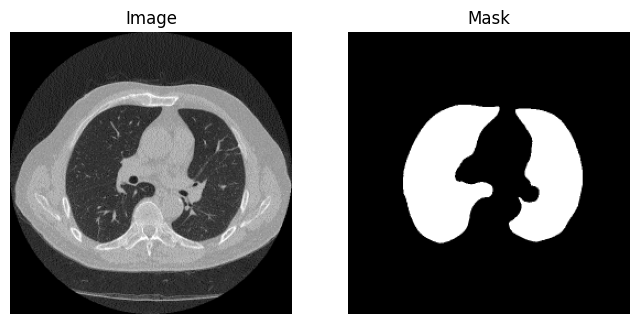

In [ ]:
# SANITY CHECK
X = random.randint(1, len(X_train)-1)
print(X)
plt.figure(figsize=(10, 10))
plt.subplot(121)
plt.imshow(np.squeeze(X_train[X,:,:]), cmap='gray')
plt.title('Image')
plt.axis('off')
plt.subplot(122)
plt.imshow(np.squeeze(Y_train[X,:,:]), cmap='gray')
plt.title('Mask')
plt.axis('off')
plt.show()

# 8. CREATE THE U-NET SEGMENTATION MODEL

<h2 style="color:#2E86C1;">U-Net Architecture for Lung Parenchyma Segmentation</h2>

<p style="font-size:16px;">
The following code implements a <b>U-Net convolutional neural network</b> using
TensorFlow/Keras. U-Net is a widely used architecture for
<b>medical image segmentation</b>, particularly effective in tasks such as
lung parenchyma segmentation from CT scans.
</p>

<p style="font-size:16px;">
The architecture follows a symmetric structure consisting of:
</p>

<ul style="font-size:15px;">
<li><b>Encoder (Contracting Path)</b> – extracts hierarchical features from the image.</li>
<li><b>Bottleneck</b> – captures the deepest and most abstract representation.</li>
<li><b>Decoder (Expanding Path)</b> – reconstructs the segmentation mask.</li>
<li><b>Skip Connections</b> – combine encoder and decoder features to preserve spatial information.</li>
</ul>

<hr>

<h3 style="color:#117A65;">1. Input Layer</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
inputs = Input(input_shape)
</pre>

<p style="font-size:15px;">
The input layer defines the shape of the images entering the network.
</p>

<ul style="font-size:15px;">
<li><b>256 × 256</b> – spatial dimensions of the CT slice</li>
<li><b>1</b> – grayscale channel</li>
</ul>

<p style="font-size:15px;">
Therefore, each training sample has the shape:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
(256, 256, 1)
</pre>

<hr>

<h3 style="color:#117A65;">2. Encoder (Feature Extraction)</h3>

<p style="font-size:15px;">
The encoder gradually reduces the spatial dimensions while increasing the
number of feature maps. This allows the network to capture increasingly
complex patterns from the input image.
</p>

<p style="font-size:15px;">
Each encoder block consists of:
</p>

<ul style="font-size:15px;">
<li><b>Conv2D</b> – extracts image features</li>
<li><b>ReLU activation</b> – introduces non-linearity</li>
<li><b>MaxPooling</b> – reduces spatial dimensions</li>
</ul>

<p style="font-size:15px;">
Example encoder block:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
c1 = Conv2D(8, (3,3), activation='relu', padding='same')(inputs)
p1 = MaxPooling2D((2,2))(c1)
</pre>

<p style="font-size:15px;">
After pooling, the spatial resolution is reduced:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
256 → 128 → 64 → 32 → 16 → 8
</pre>

<p style="font-size:15px;">
At the same time, the number of filters increases:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
8 → 16 → 32 → 64 → 128
</pre>

This enables the network to capture deeper features.

<hr>

<h3 style="color:#117A65;">3. Bottleneck Layer</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
c6 = Conv2D(256, (3,3), activation='relu', padding='same')(p5)
</pre>

<p style="font-size:15px;">
The bottleneck is the deepest part of the network.  
Here, the model learns high-level semantic features of the image
that help distinguish lung tissue from surrounding structures.
</p>

<p style="font-size:15px;">
This layer contains the largest number of filters (256),
allowing the network to learn rich representations.
</p>

<hr>

<h3 style="color:#117A65;">4. Decoder (Image Reconstruction)</h3>

<p style="font-size:15px;">
The decoder reconstructs the segmentation mask by gradually increasing
the spatial resolution of the feature maps.
</p>

<p style="font-size:15px;">
Each decoder block contains:
</p>

<ul style="font-size:15px;">
<li><b>Conv2DTranspose</b> – performs upsampling</li>
<li><b>Concatenation</b> – merges features from the encoder</li>
<li><b>Conv2D</b> – refines the combined features</li>
</ul>

Example decoder block:

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
u7 = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same')(c6)
u7 = concatenate([u7, c5])
c7 = Conv2D(128, (3,3), activation='relu', padding='same')(u7)
</pre>

<hr>

<h3 style="color:#117A65;">5. Skip Connections</h3>

<p style="font-size:15px;">
A key feature of U-Net is the use of <b>skip connections</b>.
</p>

<p style="font-size:15px;">
These connections pass feature maps from the encoder directly
to the corresponding decoder layer:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
u7 = concatenate([u7, c5])
</pre>

<p style="font-size:15px;">
This helps the model:
</p>

<ul style="font-size:15px;">
<li>Preserve spatial details</li>
<li>Improve localization of structures</li>
<li>Generate sharper segmentation boundaries</li>
</ul>

<hr>

<h3 style="color:#117A65;">6. Output Layer</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
outputs = Conv2D(1, (1,1), activation='sigmoid')(c11)
</pre>

<p style="font-size:15px;">
The final layer produces the segmentation mask.
</p>

<ul style="font-size:15px;">
<li><b>1 filter</b> – because this is a binary segmentation problem</li>
<li><b>1×1 convolution</b> – combines features into a single probability map</li>
<li><b>Sigmoid activation</b> – outputs pixel-wise probabilities between 0 and 1</li>
</ul>

<p style="font-size:15px;">
Each pixel represents the probability that it belongs to the lung region.
</p>

<hr>

<h3 style="color:#117A65;">7. Model Creation</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
model = Model(inputs, outputs)
</pre>

<p style="font-size:15px;">
This line connects the input and output layers to create the complete
U-Net model.
</p>

<hr>

<h3 style="color:#117A65;">8. Model Summary</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
model.summary()
</pre>

<p style="font-size:15px;">
This command prints the full architecture of the network, including:
</p>

<ul style="font-size:15px;">
<li>Layer names</li>
<li>Output tensor shapes</li>
<li>Number of trainable parameters</li>
</ul>

<p style="font-size:15px;">
This helps verify that the architecture has been constructed correctly
before starting the training process.
</p>

<hr>

<h3 style="color:#117A65;">Key Takeaway</h3>

<p style="font-size:15px;">
U-Net combines <b>deep feature extraction</b> with <b>precise spatial localization</b>,
making it highly effective for medical image segmentation tasks such as
lung parenchyma segmentation from CT images.
</p>

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model

def unet_model(input_shape=(256, 256, 1)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(8, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)  # 128

    c2 = Conv2D(16, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)  # 64

    c3 = Conv2D(32, (3, 3), activation='relu', padding='same')(p2)
    p3 = MaxPooling2D((2, 2))(c3)  # 32

    c4 = Conv2D(64, (3, 3), activation='relu', padding='same')(p3)
    p4 = MaxPooling2D((2, 2))(c4)  # 16

    c5 = Conv2D(128, (3, 3), activation='relu', padding='same')(p4)
    p5 = MaxPooling2D((2, 2))(c5)  # 8

    # Bottleneck
    c6 = Conv2D(256, (3, 3), activation='relu', padding='same')(p5)

    # Decoder
    u7 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c5])
    c7 = Conv2D(128, (3, 3), activation='relu', padding='same')(u7)

    u8 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c4])
    c8 = Conv2D(64, (3, 3), activation='relu', padding='same')(u8)

    u9 = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c3])
    c9 = Conv2D(32, (3, 3), activation='relu', padding='same')(u9)

    u10 = Conv2DTranspose(16, (3, 3), strides=(2, 2), padding='same')(c9)
    u10 = concatenate([u10, c2])
    c10 = Conv2D(16, (3, 3), activation='relu', padding='same')(u10)

    u11 = Conv2DTranspose(8, (3, 3), strides=(2, 2), padding='same')(c10)
    u11 = concatenate([u11, c1])
    c11 = Conv2D(8, (3, 3), activation='relu', padding='same')(u11)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c11)

    model = Model(inputs, outputs)
    return model


# Create model
model = unet_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │         80 │ input_layer[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      1,168 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 8, 8, 128) │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    295,040 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │     73,792 │ conv2d_6[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]  

 Total params: 1,179,577 (4.50 MB)

 Trainable params: 1,179,577 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

# 9. **CNN MODEL COMPILATION**

**1.LOSS FUNCTION**

**2. OPTIMIZER**

**3. METRICS TO BE MONITORED DURING TRAINING**

**4. MODEL COMPILE**

**5. MODEL CHECKPOINTING**


<h2 style="color:#2E86C1;">Dice Coefficient and Dice Loss</h2>

<p style="font-size:16px;">
In medical image segmentation tasks such as <b>lung parenchyma segmentation</b>,
evaluating how well the predicted mask overlaps with the ground truth mask is very important.
One of the most widely used evaluation metrics for segmentation is the
<b>Dice Coefficient</b>, also known as the <b>Sørensen–Dice Index</b>.
</p>

<p style="font-size:16px;">
The Dice coefficient measures the <b>overlap between two binary regions</b>:
</p>

<ul style="font-size:15px;">
<li>The <b>ground truth mask</b> (true segmentation)</li>
<li>The <b>predicted mask</b> generated by the neural network</li>
</ul>

<hr>

<h3 style="color:#117A65;">Dice Coefficient Formula</h3>

<p style="font-size:15px;">
The Dice score is defined as:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
Dice = (2 × Intersection) / (Sum of pixels in prediction + Sum of pixels in ground truth)
</pre>

<p style="font-size:15px;">
The Dice value ranges between:
</p>

<ul style="font-size:15px;">
<li><b>0</b> → No overlap between prediction and ground truth</li>
<li><b>1</b> → Perfect overlap</li>
</ul>

<hr>

<h3 style="color:#117A65;">Smoothing Parameter</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
smooth = 1
eps = 1e-7
</pre>

<p style="font-size:15px;">
A small smoothing constant is added to the formula to avoid
<b>division by zero</b> when both masks contain no foreground pixels.
</p>

<ul style="font-size:15px;">
<li><b>smooth</b> stabilizes the Dice calculation.</li>
<li><b>eps</b> prevents numerical instability.</li>
</ul>

<hr>

<h3 style="color:#117A65;">Dice Coefficient Function</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
</pre>

<p style="font-size:15px;">
The first step converts both the ground truth mask and predicted mask
into <b>one-dimensional vectors</b> using the <code>flatten()</code> function.  
This simplifies the calculation by treating the entire mask as a single vector.
</p>

<hr>

<h4 style="color:#7D3C98;">Intersection Calculation</h4>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
intersection = K.sum(y_true_f * y_pred_f)
</pre>

<p style="font-size:15px;">
The intersection represents the number of pixels that are correctly predicted
as belonging to the target region (e.g., lung tissue).
</p>

<ul style="font-size:15px;">
<li>If both prediction and ground truth contain a pixel → contributes to intersection</li>
<li>If only one contains the pixel → not counted</li>
</ul>

<hr>

<h4 style="color:#7D3C98;">Dice Score Computation</h4>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
return (2 * intersection + smooth) /
       (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
</pre>

<p style="font-size:15px;">
The Dice coefficient doubles the intersection and divides it by the total
number of pixels in both masks. This emphasizes correct overlap between
prediction and ground truth.
</p>

<hr>

<h3 style="color:#117A65;">Dice Loss Function</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
def dice_coef_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)
</pre>

<p style="font-size:15px;">
Since neural networks are trained by <b>minimizing a loss function</b>,
the Dice coefficient is converted into a loss value.
</p>

<p style="font-size:15px;">
This is done by subtracting the Dice score from 1:
</p>

<ul style="font-size:15px;">
<li><b>Dice Score = 1</b> → Perfect segmentation → Loss = 0</li>
<li><b>Dice Score = 0</b> → No overlap → Loss = 1</li>
</ul>

<p style="font-size:15px;">
Thus, minimizing Dice loss during training forces the model
to maximize the overlap between predicted and ground truth masks.
</p>

<hr>

<h3 style="color:#117A65;">Why Dice Loss is Important in Medical Segmentation</h3>

<ul style="font-size:15px;">
<li>Handles <b>class imbalance</b> effectively (common in medical images)</li>
<li>Focuses on <b>region overlap</b> rather than individual pixel accuracy</li>
<li>Improves segmentation of small structures such as lung boundaries</li>
<li>Widely used in medical imaging research</li>
</ul>

<hr>

<h3 style="color:#117A65;">Key Takeaway</h3>

<p style="font-size:15px;">
The Dice coefficient measures how closely the predicted segmentation mask
matches the ground truth mask. By minimizing Dice loss during training,
the neural network learns to produce more accurate and precise segmentation results.
</p>

In [ ]:
# DICE COEFFICIENT and DICE LOSS
smooth = 1
eps = 1e-7
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * (intersection)+smooth ) / (K.sum(y_true_f) + K.sum(y_pred_f)+smooth)

def dice_coef_loss(y_true, y_pred):
    return 1-dice_coef(y_true, y_pred)

<h2 style="color:#2E86C1;">Model Compilation: Optimizer, Loss Function, and Metrics</h2>

<p style="font-size:16px;">
Before training a neural network, the model must be <b>compiled</b>.
Compilation defines three key components required for training:
</p>

<ul style="font-size:15px;">
<li><b>Optimizer</b> – determines how model weights are updated during training.</li>
<li><b>Loss Function</b> – measures how well the predicted output matches the ground truth.</li>
<li><b>Evaluation Metrics</b> – provides performance indicators during training.</li>
</ul>

<hr>

<h3 style="color:#117A65;">1. Optimizer</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
optimizer = keras.optimizers.Adam(0.0001)
</pre>

<p style="font-size:15px;">
The optimizer controls how the neural network updates its weights using
<b>gradient descent</b>.
</p>

<p style="font-size:15px;">
In this implementation, the <b>Adam optimizer</b> is used. Adam is one of the most
popular optimization algorithms for deep learning because it combines the
advantages of two methods:
</p>

<ul style="font-size:15px;">
<li><b>Momentum</b> – helps accelerate learning in relevant directions.</li>
<li><b>Adaptive learning rates</b> – adjusts step sizes automatically for each parameter.</li>
</ul>

<p style="font-size:15px;">
The learning rate is set to:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
0.0001
</pre>

<p style="font-size:15px;">
A smaller learning rate ensures <b>stable and gradual learning</b>, which is
particularly important for medical image segmentation tasks.
</p>

<hr>

<h3 style="color:#117A65;">2. Loss Function</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
dice_loss = dice_coef_loss
</pre>

<p style="font-size:15px;">
The loss function measures how far the predicted segmentation mask is from
the ground truth mask.
</p>

<p style="font-size:15px;">
Here, the model uses <b>Dice Loss</b>, which is derived from the Dice coefficient.
Dice loss is particularly effective for segmentation problems because it
focuses on the <b>overlap between predicted and true regions</b>.
</p>

<ul style="font-size:15px;">
<li><b>Dice Score = 1</b> → perfect segmentation</li>
<li><b>Dice Score = 0</b> → no overlap</li>
</ul>

<p style="font-size:15px;">
Since neural networks minimize loss, the loss is defined as:
</p>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
Loss = 1 − Dice Score
</pre>

<p style="font-size:15px;">
Minimizing Dice loss therefore encourages the network to maximize the overlap
between predicted and ground truth masks.
</p>

<hr>

<h3 style="color:#117A65;">3. Evaluation Metric</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
metrics = [dice_coef]
</pre>

<p style="font-size:15px;">
While the loss function guides the learning process, evaluation metrics help
monitor model performance during training.
</p>

<p style="font-size:15px;">
In this case, the model tracks the <b>Dice coefficient</b>, which directly
measures segmentation accuracy based on the overlap between prediction
and ground truth masks.
</p>

<p style="font-size:15px;">
Tracking the Dice score during training allows us to see how well the model
is improving at identifying the lung region in CT images.
</p>

<hr>

<h3 style="color:#117A65;">4. Model Compilation</h3>

<pre style="background:#F4F6F7;padding:10px;border-radius:6px;">
model.compile(optimizer, loss=dice_loss, metrics=metrics)
</pre>

<p style="font-size:15px;">
This step finalizes the configuration of the neural network before training begins.
</p>

<p style="font-size:15px;">
The model now knows:
</p>

<ul style="font-size:15px;">
<li>How to update its weights (<b>optimizer</b>)</li>
<li>How to measure prediction errors (<b>loss function</b>)</li>
<li>How to evaluate segmentation performance (<b>metrics</b>)</li>
</ul>

<p style="font-size:15px;">
Once the model is compiled, it is ready for the <b>training process</b>,
where it will learn to segment lung regions from CT images.
</p>

<hr>

<h3 style="color:#117A65;">Key Takeaway</h3>

<p style="font-size:15px;">
Model compilation defines the learning strategy of the neural network.
Using the Adam optimizer together with Dice loss and Dice coefficient
metrics provides a robust setup for training U-Net models in medical
image segmentation tasks.
</p>

In [ ]:
# define optomizer
optimizer = keras.optimizers.Adam(0.0001)

# Define loss
dice_loss = dice_coef_loss

# define metrics
metrics = [dice_coef]

#Compile the model

model.compile(optimizer, loss = dice_loss, metrics = metrics)

<h3>Checkpointing and Saving the Model</h3>

<p>
This section ensures that the <b>best-performing model during training is automatically saved</b>.
In deep learning experiments, training can take a long time, and sometimes later epochs may
degrade performance due to overfitting. Therefore, checkpointing helps preserve the
<b>optimal model state</b> without manually monitoring training.
</p>

<p>
First, a <b>file path (PATH)</b> is defined where the trained model will be stored. In this case,
the model will be saved as <code>lung_seg_model.keras</code>. The <code>.keras</code> format stores
the <b>entire model architecture, weights, and training configuration</b>, allowing the model
to be easily reloaded later for inference or further training.
</p>

<p>
Next, the <b>ModelCheckpoint callback</b> from Keras is used. This callback automatically saves
the model during training whenever a specified performance metric improves.
</p>

<p>
The parameter <code>save_best_only=True</code> ensures that only the model with the
<b>lowest validation loss</b> is saved. This prevents overwriting the best-performing model
with a worse one from later epochs.
</p>

<p>
The argument <code>monitor='val_loss'</code> specifies that the checkpointing decision will be
based on the <b>validation loss</b>, which is a reliable indicator of how well the model
generalizes to unseen data.
</p>

<p>
The <code>mode='min'</code> setting tells Keras that <b>lower values of validation loss are better</b>,
so the model will be saved whenever the validation loss decreases.
</p>

<p>
Finally, <code>save_weights_only=False</code> ensures that the <b>entire model (architecture + weights)</b>
is stored rather than just the weights. This allows the saved model to be loaded directly using
<code>keras.models.load_model()</code> without reconstructing the architecture manually.
</p>

<p>
Overall, checkpointing is an important training strategy because it
<b>automatically preserves the best version of the model</b>, protects against performance
degradation during later training epochs, and ensures that the optimal model is available
for evaluation or deployment.
</p>

In [ ]:
# CHECKPOINTING and SAVING
PATH = '/lung_seg_model.keras'
model_checkpoint = [keras.callbacks.ModelCheckpoint(PATH, save_weights_only=False, save_best_only=True, monitor='val_loss', mode='min')]

# TRAIN THE U-NET MODEL USING **model.fit()**

In [ ]:
history = model.fit(
                      X_train,
                      Y_train,
                      batch_size=16,
                      epochs=50,
                      validation_data=(X_val, Y_val),
                      callbacks=[model_checkpoint],
                    )

Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 57s 101ms/step - dice_coef: 0.4228 - loss: 0.5772 - val_dice_coef: 0.8031 - val_loss: 0.1956
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - dice_coef: 0.9405 - loss: 0.0595 - val_dice_coef: 0.8544 - val_loss: 0.1448
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - dice_coef: 0.9609 - loss: 0.0391 - val_dice_coef: 0.8839 - val_loss: 0.1155
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - dice_coef: 0.9691 - loss: 0.0309 - val_dice_coef: 0.9008 - val_loss: 0.0989
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - dice_coef: 0.9752 - loss: 0.0248 - val_dice_coef: 0.9140 - val_loss: 0.0859
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - dice_coef: 0.9788 - loss: 0.0212 - val_dice_coef: 0.9206 - val_loss: 0.0793
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - dice_coef: 0.9807 - loss: 0.0193 - val_dice_coef: 0.9257 - val_loss: 0.0742
Epoch 8/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - dice_coef: 0.9825 -

# PLOT THE MODEL LOSS AND DICE PROGRESSION OVER THE EPOCHS

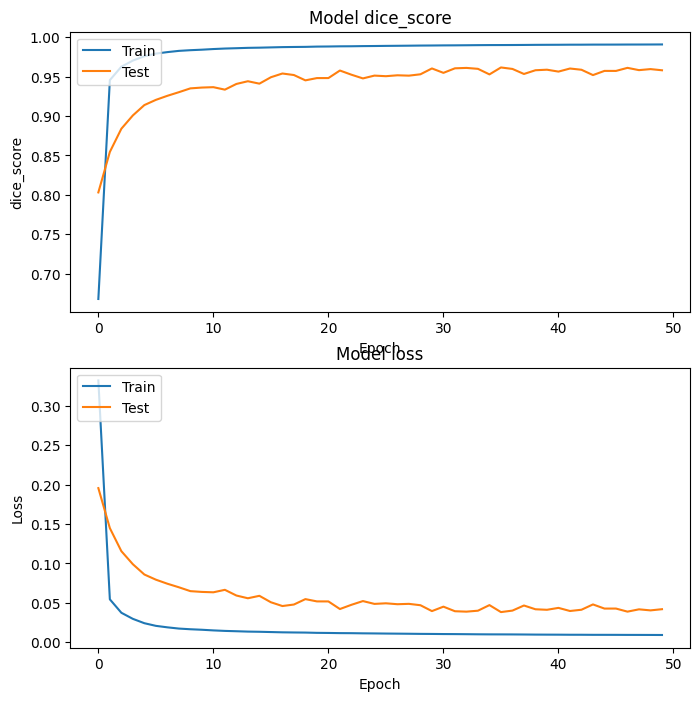

In [ ]:
# Plot training & validation iou_score values
plt.figure(figsize=(8,8))
plt.subplot(211)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Model dice_score')
plt.ylabel('dice_score')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(212)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# TEST THE MODEL'S PERFORMANCE ON THE TEST DATASET

<h3>Model Prediction and Saving the Results</h3>

<p>
This section defines a function that performs <b>model inference on the validation dataset</b>
and saves the predicted segmentation masks for later analysis. Running predictions after
training allows us to evaluate how well the model performs on unseen data.
</p>

<pre><code>
def model_predict():
  print('Prediction Initialized')
  predicted_mask = model.predict(X_val, verbose=1)
  print('Predicted mask shape:', predicted_mask.shape)
  print('Prediction Done Successfully')

  np.save('/predictions.npy', predicted_mask)
  print('Predicted masks saved successfully')
</code></pre>

<p>
First, the function prints <code>Prediction Initialized</code> to indicate that the inference
process has started.
</p>

<p>
The <code>model.predict()</code> function is then used to generate segmentation predictions
for the validation dataset <code>X_val</code>. The parameter <code>verbose=1</code> enables
a progress bar during prediction, which is useful when processing a large number of images.
</p>

<p>
After prediction, the shape of the predicted masks is printed using
<code>predicted_mask.shape</code>. This acts as a <b>sanity check</b> to verify that the
output dimensions match the expected format, typically:
</p>

<ul>
<li><b>(number_of_images, height, width, channels)</b></li>
</ul>

<p>
Once the prediction process is completed, a confirmation message
<code>Prediction Done Successfully</code> is printed.
</p>

<p>
Finally, the predicted segmentation masks are saved using
<code>np.save()</code>, which stores the predictions in a NumPy binary file
named <code>predictions.npy</code>. Saving predictions in this format allows
them to be easily reloaded later for <b>visualization, evaluation, or further
post-processing</b>.
</p>

<p>
Overall, this function simplifies the inference process by automating
prediction, performing basic output verification, and storing the results
for future use.
</p>

In [ ]:
model = tf.keras.models.load_model('/lung_seg_model.keras',
                                    custom_objects={'dice_coef_loss': dice_coef_loss, 'dice_coef': dice_coef})

In [ ]:
def model_predict():
  print('Prediction Initialized')
  predicted_mask = model.predict(X_val, verbose=1)
  print('Predicted mask shape:', predicted_mask.shape)
  print('Prediction Done Successfully')

  np.save('/predictions.npy', predicted_mask)
  print('Predicted masks saved successfully')

In [ ]:
model_predict()

Prediction Initialized
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step
Predicted mask shape: (1400, 256, 256, 1)
Prediction Done Successfully
Predicted masks saved successfully


In [ ]:
# LOAD THE PREDICTED IMAGES
predicted_mask = np.load('/predictions.npy')

Displaying Image No: 381


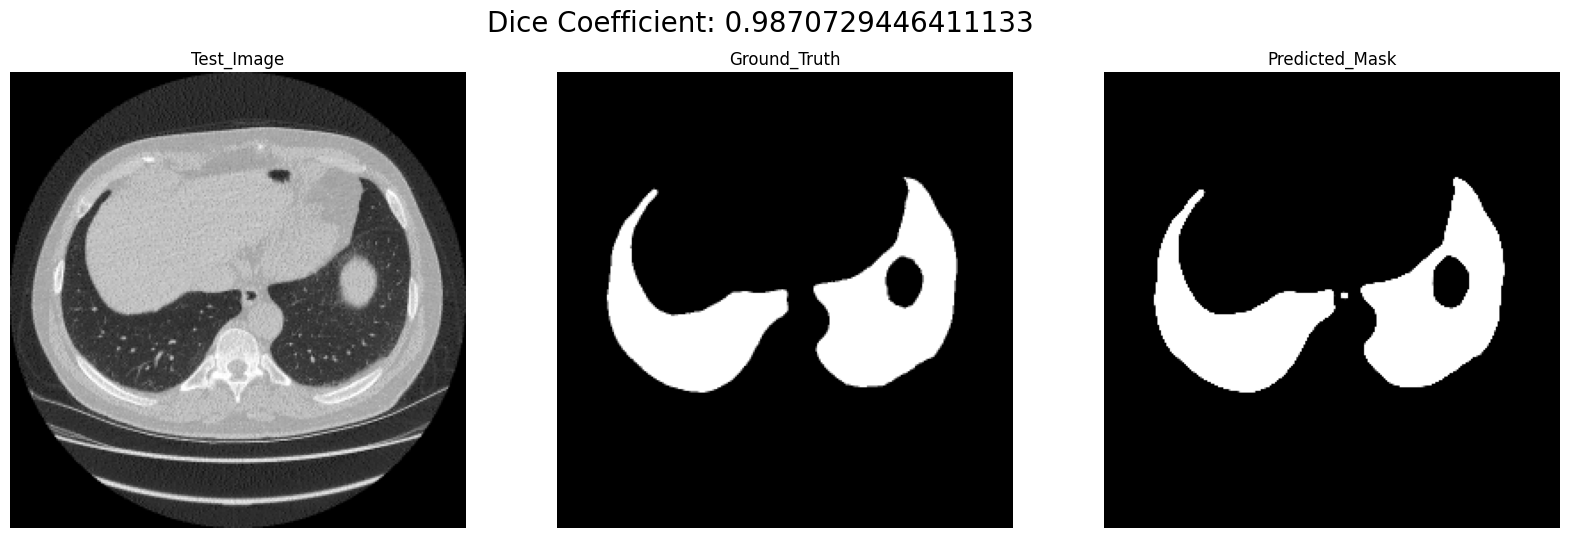

In [ ]:
# VISUALIZE THE RESULTS
X = random.randint(0, 499)
print(f'Displaying Image No: {X}')
plt.figure(figsize=(20, 6))
plt.subplot(131)
plt.imshow(np.squeeze(X_val[X,:,:]), cmap='gray')
plt.title('Test_Image')
plt.axis('off')
plt.subplot(132)
plt.imshow(np.squeeze(Y_val[X,:,:]), cmap='gray')
plt.title('Ground_Truth')
plt.axis('off')
plt.subplot(133)
plt.imshow(np.squeeze(predicted_mask[X,:,:]), cmap='gray')
plt.title('Predicted_Mask')
plt.suptitle(f'Dice Coefficient: {dice_coef(Y_val[X,:,:], predicted_mask[X,:,:])}', fontsize=20)
plt.axis('off')
plt.show()

In [ ]:
XX = np.squeeze(X_val[X,:,:]) * np.squeeze(predicted_mask[X,:,:])

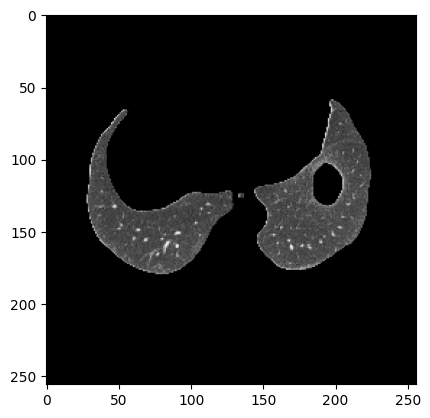

In [ ]:
plt.imshow(XX, cmap='gray')